In [1]:
!pip install -q numpy matplotlib scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 4.7 MB/s eta 0:00:00


Nota do serviço (0-10) [7]: 7
Nota da comida (0-10) [3]: 3

          RESULTADO DO SISTEMA FUZZY
Nota do serviço: 7.0
Nota da comida: 3.0
Gorjeta sugerida: 12.5%

     GRAUS DE PERTINÊNCIA DO SERVIÇO
Ruim  : 0.00
Médio : 0.60
Bom   : 0.40

      GRAUS DE PERTINÊNCIA DA COMIDA
Ruim  : 0.40
Médio : 0.60
Bom   : 0.00


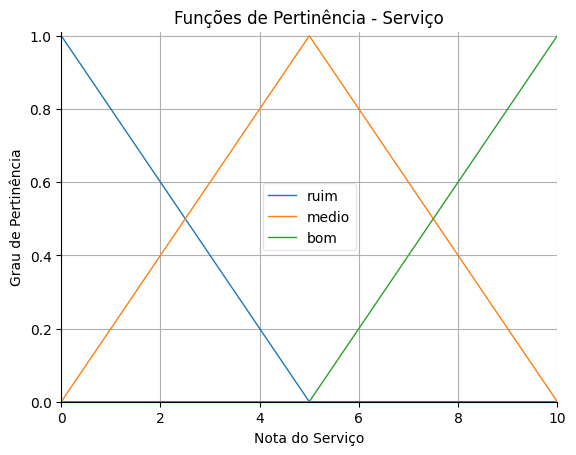

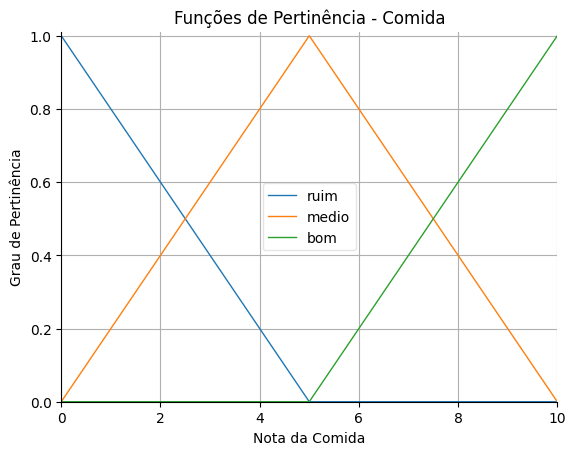

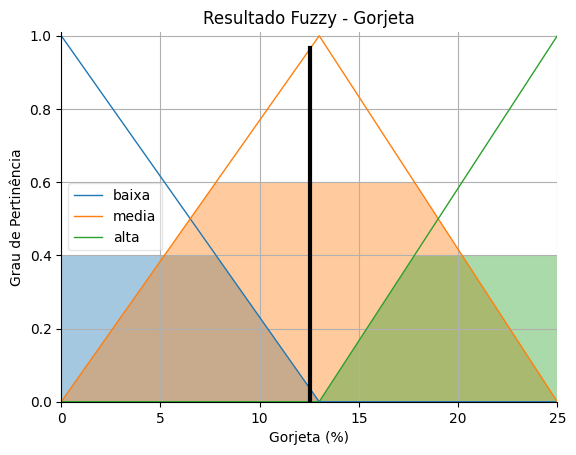


                    CONCLUSÃO

O sistema fuzzy analisou duas variáveis de entrada:

- Qualidade do serviço = 7.0
- Qualidade da comida = 3.0

12.5%.



In [3]:


import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl


servico = ctrl.Antecedent(
    np.arange(0, 10.01, 0.1),
    "servico"
)

# Entrada: qualidade da comida
# Universo de discurso: 0 até 10
comida = ctrl.Antecedent(
    np.arange(0, 10.01, 0.1),
    "comida"
)

# Saída: porcentagem da gorjeta
# Universo de discurso: 0% até 25%
gorjeta = ctrl.Consequent(
    np.arange(0, 25.01, 0.5),
    "gorjeta"
)




servico["ruim"] = fuzz.trimf(
    servico.universe,
    [0, 0, 5]
)

servico["medio"] = fuzz.trimf(
    servico.universe,
    [0, 5, 10]
)

servico["bom"] = fuzz.trimf(
    servico.universe,
    [5, 10, 10]
)




comida["ruim"] = fuzz.trimf(
    comida.universe,
    [0, 0, 5]
)

comida["medio"] = fuzz.trimf(
    comida.universe,
    [0, 5, 10]
)

comida["bom"] = fuzz.trimf(
    comida.universe,
    [5, 10, 10]
)


# ==============================================================================
# 5) CONJUNTOS FUZZY - GORJETA
# ==============================================================================

gorjeta["baixa"] = fuzz.trimf(
    gorjeta.universe,
    [0, 0, 13]
)

gorjeta["media"] = fuzz.trimf(
    gorjeta.universe,
    [0, 13, 25]
)

gorjeta["alta"] = fuzz.trimf(
    gorjeta.universe,
    [13, 25, 25]
)


# ==============================================================================
# 6) BASE DE REGRAS FUZZY
# ==============================================================================



regra1 = ctrl.Rule(
    servico["ruim"] | comida["ruim"],
    gorjeta["baixa"]
)


# Regra 2:


regra2 = ctrl.Rule(
    servico["medio"],
    gorjeta["media"]
)


# Regra 3:


regra3 = ctrl.Rule(
    servico["bom"] | comida["bom"],
    gorjeta["alta"]
)


# ==============================================================================
# 7) CRIAÇÃO DO SISTEMA DE CONTROLE
# ==============================================================================

regras = [
    regra1,
    regra2,
    regra3
]

sistema = ctrl.ControlSystem(regras)

sim = ctrl.ControlSystemSimulation(sistema)


# ==============================================================================
# 8) FUNÇÃO PARA PEDIR AS NOTAS
# ==============================================================================

def pedir_nota(texto, padrao):
    """

    """

    resposta = input(
        f"{texto} (0-10) [{padrao}]: "
    ).strip()

    # Se o usuário não digitar nada
    if resposta == "":
        return padrao

    # Permite utilizar vírgula ou ponto
    valor = float(
        resposta.replace(",", ".")
    )

    # Validação da nota
    if valor < 0 or valor > 10:
        print(
            "Nota inválida. "
            f"Será utilizado o valor padrão {padrao}."
        )
        return padrao

    return valor


# ==============================================================================
# 9) ENTRADA DOS VALORES
# ==============================================================================

nota_servico = pedir_nota(
    "Nota do serviço",
    7
)

nota_comida = pedir_nota(
    "Nota da comida",
    3
)


# Passando os valores para o sistema fuzzy

sim.input["servico"] = nota_servico

sim.input["comida"] = nota_comida


# ==============================================================================
# 10) EXECUÇÃO DA INFERÊNCIA FUZZY
# ==============================================================================

sim.compute()


# Resultado final

resultado = sim.output["gorjeta"]


print("\n" + "=" * 60)
print("          RESULTADO DO SISTEMA FUZZY")
print("=" * 60)

print(
    f"Nota do serviço: {nota_servico:.1f}"
)

print(
    f"Nota da comida: {nota_comida:.1f}"
)

print(
    f"Gorjeta sugerida: {resultado:.1f}%"
)


# ==============================================================================
# 11) GRAUS DE PERTINÊNCIA DO SERVIÇO
# ==============================================================================

servico_ruim = fuzz.interp_membership(
    servico.universe,
    servico["ruim"].mf,
    nota_servico
)

servico_medio = fuzz.interp_membership(
    servico.universe,
    servico["medio"].mf,
    nota_servico
)

servico_bom = fuzz.interp_membership(
    servico.universe,
    servico["bom"].mf,
    nota_servico
)


print("\n" + "=" * 60)
print("     GRAUS DE PERTINÊNCIA DO SERVIÇO")
print("=" * 60)

print(
    f"Ruim  : {servico_ruim:.2f}"
)

print(
    f"Médio : {servico_medio:.2f}"
)

print(
    f"Bom   : {servico_bom:.2f}"
)


# ==============================================================================
# 12) GRAUS DE PERTINÊNCIA DA COMIDA
# ==============================================================================

comida_ruim = fuzz.interp_membership(
    comida.universe,
    comida["ruim"].mf,
    nota_comida
)

comida_media = fuzz.interp_membership(
    comida.universe,
    comida["medio"].mf,
    nota_comida
)

comida_boa = fuzz.interp_membership(
    comida.universe,
    comida["bom"].mf,
    nota_comida
)


print("\n" + "=" * 60)
print("      GRAUS DE PERTINÊNCIA DA COMIDA")
print("=" * 60)

print(
    f"Ruim  : {comida_ruim:.2f}"
)

print(
    f"Médio : {comida_media:.2f}"
)

print(
    f"Bom   : {comida_boa:.2f}"
)


# ==============================================================================
# 13) GRÁFICO - SERVIÇO
# ==============================================================================

servico.view()

plt.title(
    "Funções de Pertinência - Serviço"
)

plt.xlabel(
    "Nota do Serviço"
)

plt.ylabel(
    "Grau de Pertinência"
)

plt.grid()

plt.show()


# ==============================================================================
# 14) GRÁFICO - COMIDA
# ==============================================================================

comida.view()

plt.title(
    "Funções de Pertinência - Comida"
)

plt.xlabel(
    "Nota da Comida"
)

plt.ylabel(
    "Grau de Pertinência"
)

plt.grid()

plt.show()


# ==============================================================================
# 15) GRÁFICO - RESULTADO DA GORJETA
# ==============================================================================

gorjeta.view(
    sim=sim
)

plt.title(
    "Resultado Fuzzy - Gorjeta"
)

plt.xlabel(
    "Gorjeta (%)"
)

plt.ylabel(
    "Grau de Pertinência"
)

plt.grid()

plt.show()


# ==============================================================================
# 16) CONCLUSÃO
# ==============================================================================

print("\n" + "=" * 60)
print("                    CONCLUSÃO")
print("=" * 60)

print(f"""
O sistema fuzzy analisou duas variáveis de entrada:

- Qualidade do serviço = {nota_servico:.1f}
- Qualidade da comida = {nota_comida:.1f}

{resultado:.1f}%.
""")